In [1]:
from libraries import *
from parameters import *
from util import *
from GetGOPrograms import *
from GenerateGRN import *
from ControlDataGenerator import *
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch
import matplotlib.patches as mpatches
from typing import Dict, List, Set
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Rectangle
from scipy.stats import multivariate_normal, nbinom, poisson



/home/beraslan/miniconda/envs/py312/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
go_gen = GOProgramGenerator(
        n_programs= 15,
        organism = "human", 
        total_genes = 5000,
        min_program_size = 20,
        max_program_size = 150,
        add_synthetic_program_genes= True,
        n_synthetic_per_program = [30, 80],
        synthetic_overlap_mean = 0.85,
        synthetic_overlap_std = 0.05,
        add_filler_genes =True,
        seed =42,
        data_dir ="./go_data",
        use_cached=True,
        verbose= True)

Input sequence provided is already in string format. No operation performed


go_data/go-basic.obo: fmt(1.2) rel(2026-01-23) 42,036 Terms


Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [3]:
programs = go_gen.get_programs(k=15)
all_genes = go_gen.get_all_genes()

In [4]:
grn = GeneRegulatoryNetwork(
    programs=programs,  # From your GOProgramGenerator
    all_genes=all_genes,  # From your GOProgramGenerator
    w_activation_prob=0.7,
    v_negative_prob=0.7,
    w_mean_range=(0.6, 1.0),    # W magnitudes centered around 0.6-1.0
    w_std_range=(0.1, 0.3),     # W std varies between programs
    v_mean_range=(0.15, 0.35),  # V magnitudes smaller (0.15-0.35)
    v_std_range=(0.05, 0.15),   # V std varies between programs
    min_magnitude=0.01,          # Minimum non-zero magnitude
    seed=42,
    verbose=False
)
 

In [5]:
with open("./DATA/grn.pkl", "wb") as f:                                                                                  
      pickle.dump(grn, f)

In [6]:
from ControlDataGenerator import *
generator = ControlDataGenerator(grn=grn, go_gen=go_gen, seed=42)


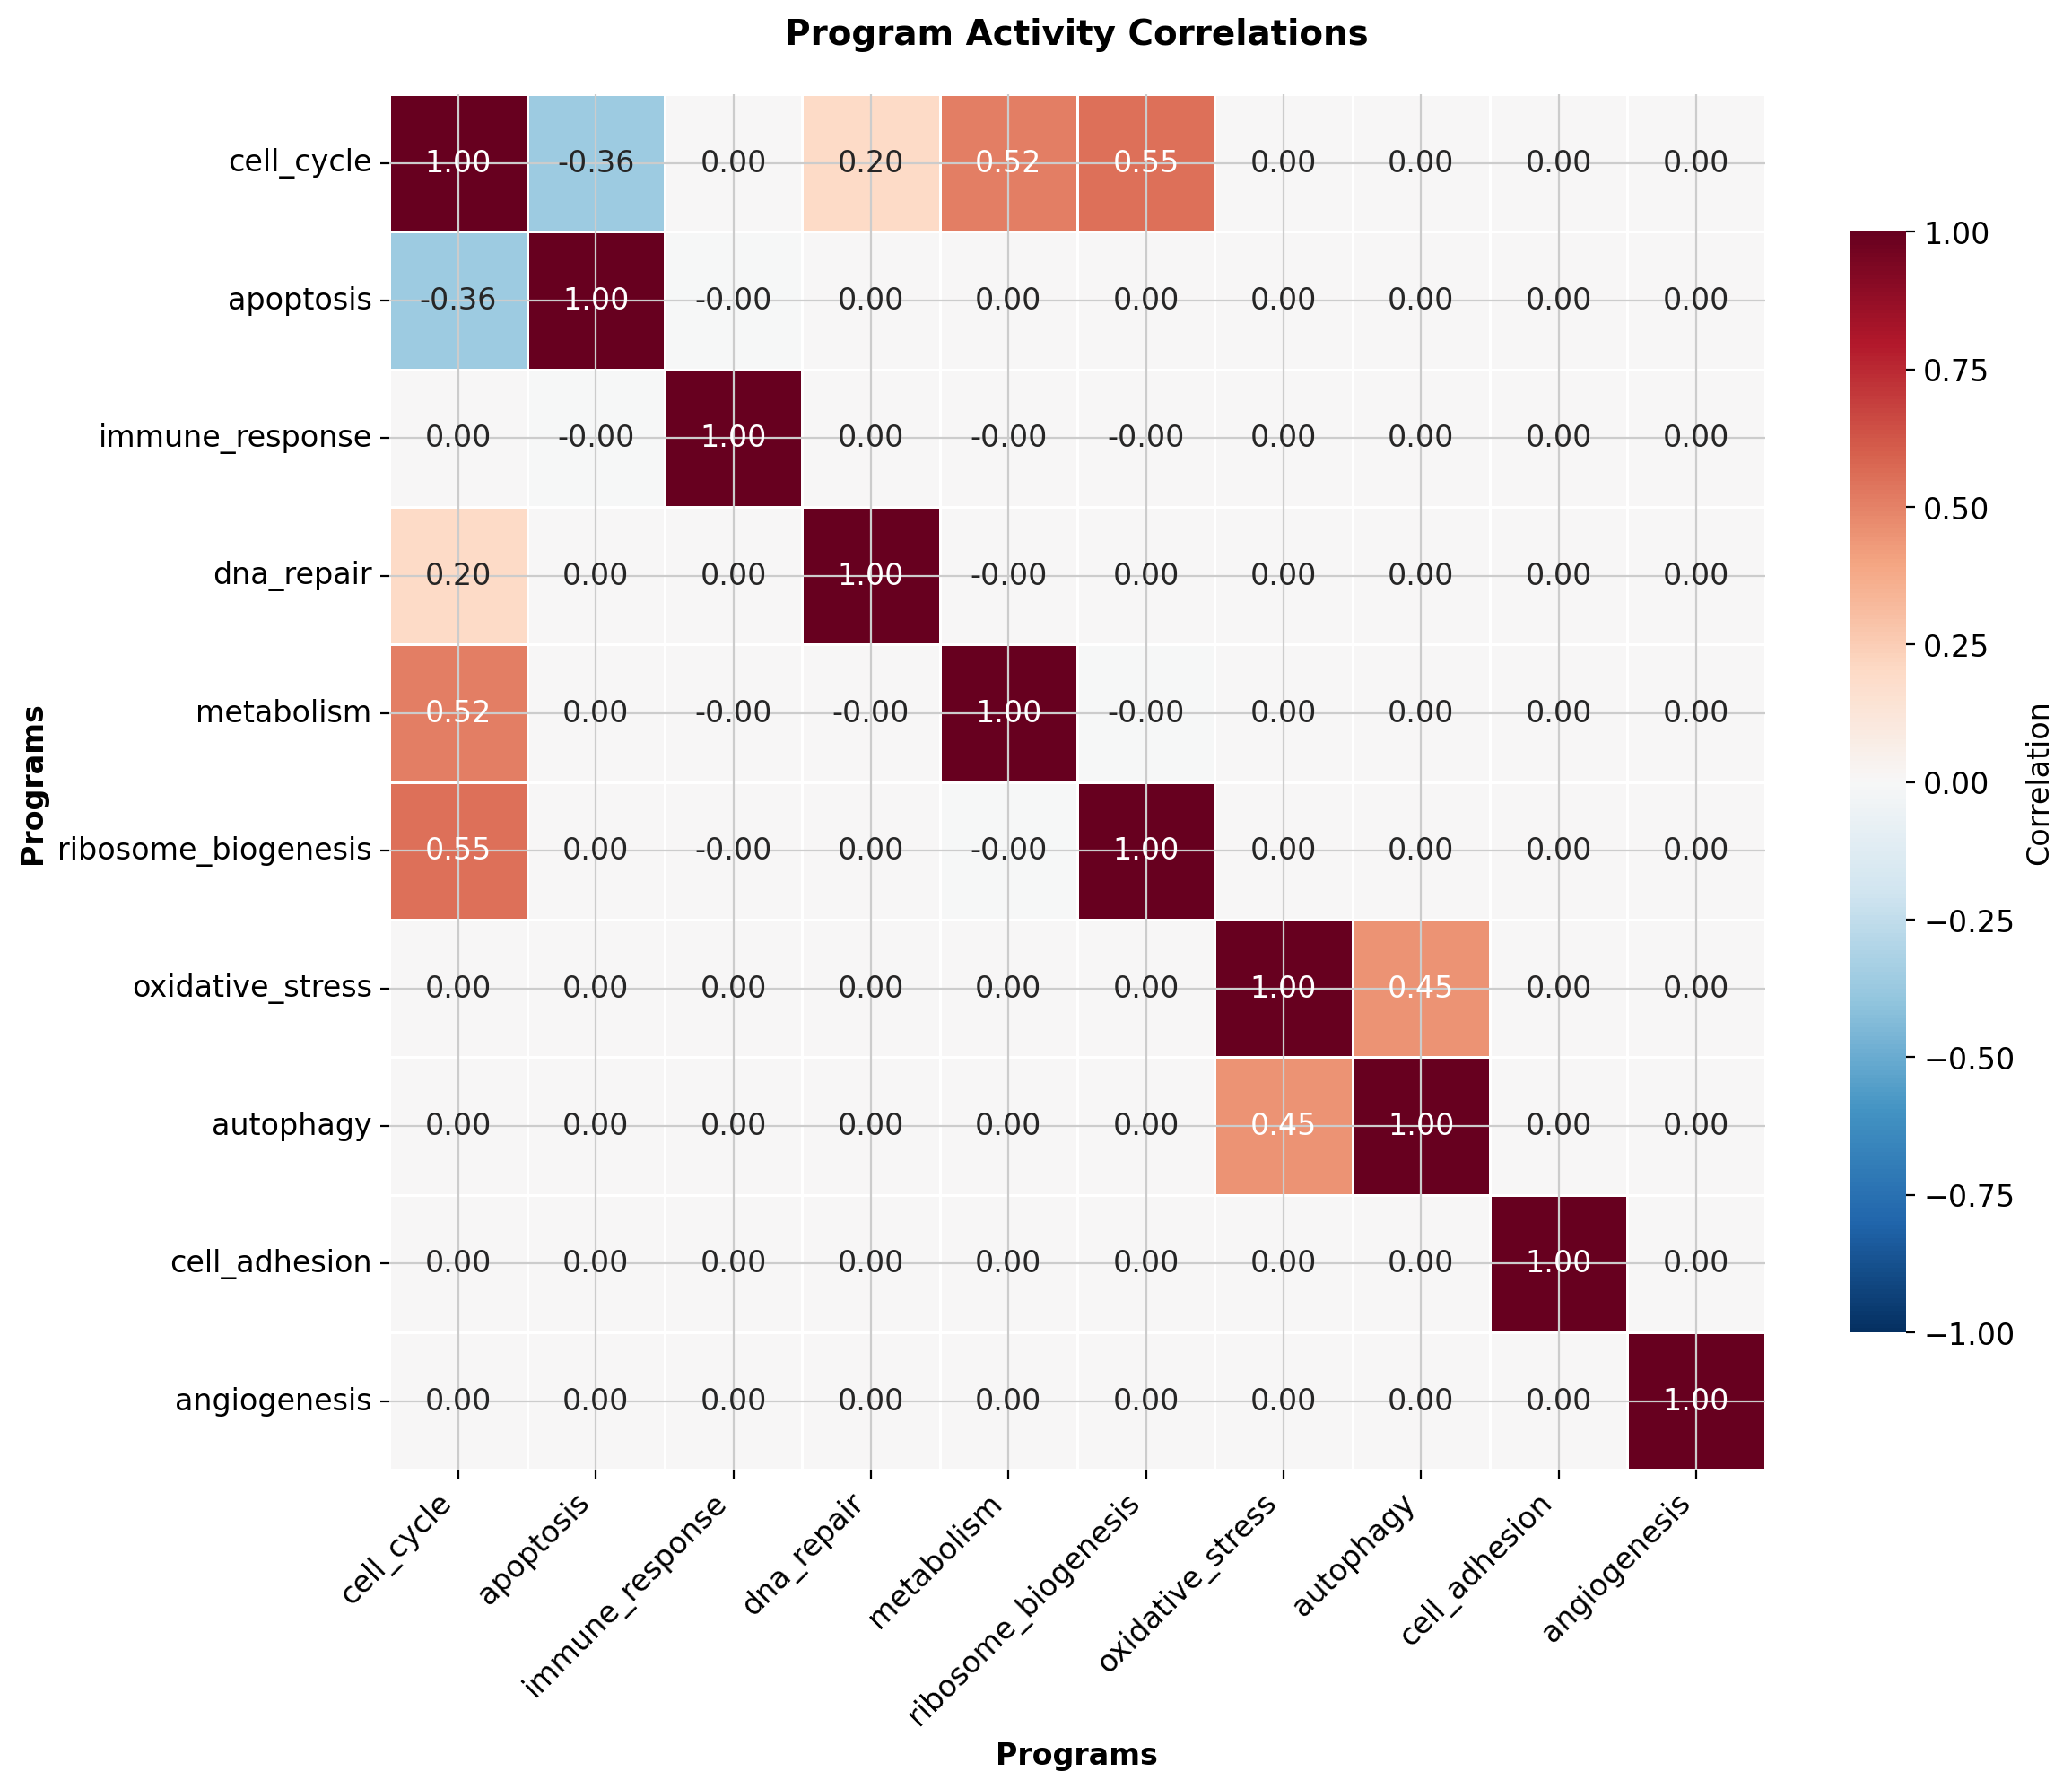

(<Figure size 1200x1000 with 2 Axes>,
 <Axes: title={'center': 'Program Activity Correlations'}, xlabel='Programs', ylabel='Programs'>)

In [7]:
generator.plot_program_correlations(
        figsize=(12, 10),
        annot=True,
        fmt='.2f',
        show=True
    )

In [8]:
control_data_homogenous = generator.generate_control_data(
    n_cells=1000,
    activity_mean=0.0,
    activity_std=0.05,
    use_correlations=True,
    count_distribution='negative_binomial',
    total_counts_per_cell=10000
)

control_data_homogenous.layers['raw_counts']=control_data_homogenous.X

In [9]:
control_data_heterogenous = generator.generate_control_data(
    n_cells=1000,
    activity_mean=1.0,
    activity_std=5.0,
    use_correlations=True,
    count_distribution="negative_binomial",
    total_counts_per_cell=10000
)
control_data_heterogenous.layers['raw_counts']=control_data_heterogenous.X

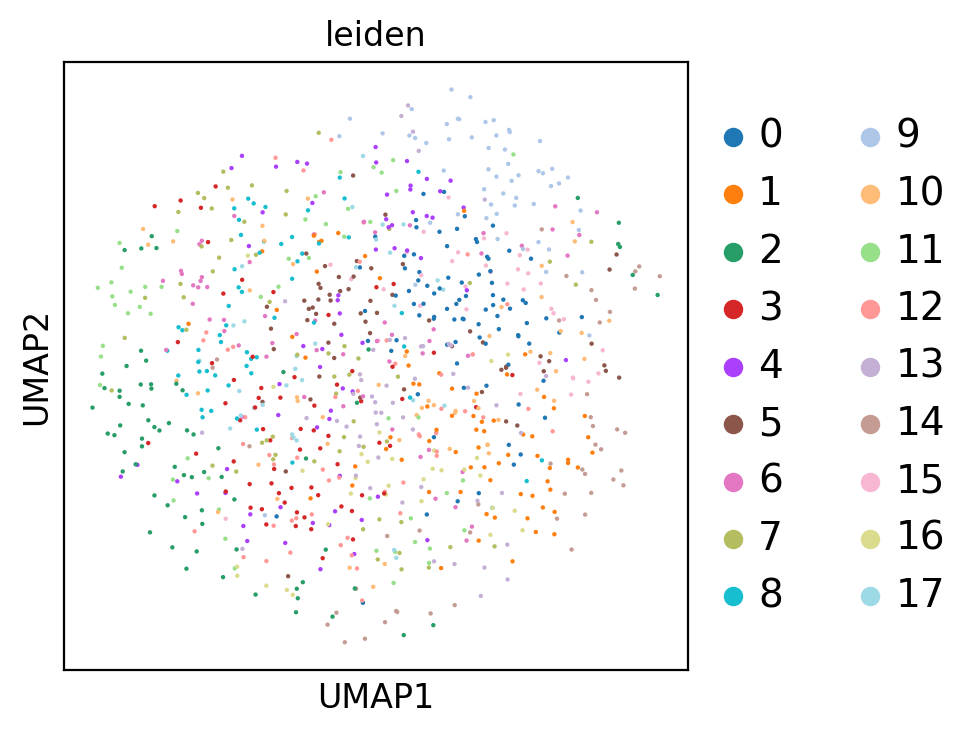

In [10]:
sc.pp.normalize_total(control_data_homogenous, target_sum=10000)
sc.pp.log1p(control_data_homogenous)
control_data_homogenous.layers['raw_logNorm']=control_data_homogenous.X

sc.pp.scale(control_data_homogenous, max_value=10)
sc.pp.pca(control_data_homogenous, n_comps=50, svd_solver='arpack')
sc.pp.neighbors(control_data_homogenous, 
            n_neighbors=5,
            n_pcs=50)
sc.tl.umap(control_data_homogenous)
sc.tl.leiden(control_data_homogenous)
sc.pl.umap(control_data_homogenous, color='leiden', 
       legend_fontoutline=3, 
       legend_fontsize=14, 
       legend_fontweight='normal', 
       size=10);

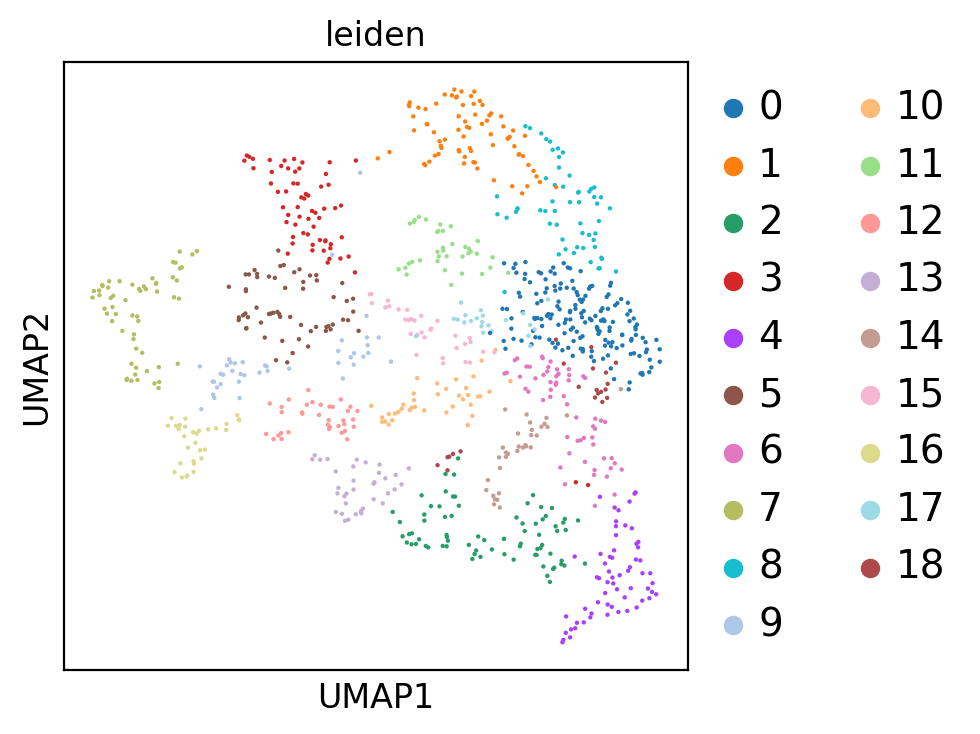

In [11]:
sc.pp.normalize_total(control_data_heterogenous, target_sum=10000)
sc.pp.log1p(control_data_heterogenous)
control_data_heterogenous.layers['raw_logNorm']=control_data_heterogenous.X

sc.pp.scale(control_data_heterogenous, max_value=10)
sc.pp.pca(control_data_heterogenous, n_comps=50, svd_solver='arpack')
sc.pp.neighbors(control_data_heterogenous, 
            n_neighbors=5,
            n_pcs=50)
sc.tl.umap(control_data_heterogenous)
sc.tl.leiden(control_data_heterogenous)
sc.pl.umap(control_data_heterogenous, color='leiden', 
       legend_fontoutline=3, 
       legend_fontsize=14, 
       legend_fontweight='normal', 
       size=10);

In [12]:
control_data_homogenous.write("./DATA/control_data_homogenous.h5ad")

In [13]:
control_data_heterogenous.write("./DATA/control_data_heterogenous.h5ad")